In [146]:
from sklearn.pipeline import Pipeline
import pandas as pd
import warnings
from sklearn.preprocessing import FunctionTransformer
import re
import numpy as np
warnings.filterwarnings("ignore")

In [147]:
purchases = pd.read_csv("../analisis exploratorio/amazon-purchases.csv")
survey = pd.read_csv("../analisis exploratorio/survey2.csv")

In [148]:
survey.drop(columns=["Q-life-changes"], inplace=True)

In [149]:
purchases = purchases.drop_duplicates()

In [150]:
purchases_samsung = purchases[
    purchases["Title"].str.contains(r"\bsamsung\b", case=False, regex=True, na=False)
].copy()

purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19681 entries, 5 to 1850564
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order Date                19681 non-null  object 
 1   Purchase Price Per Unit   19681 non-null  float64
 2   Quantity                  19681 non-null  float64
 3   Shipping Address State    19114 non-null  object 
 4   Title                     19681 non-null  object 
 5   ASIN/ISBN (Product Code)  19679 non-null  object 
 6   Category                  19674 non-null  object 
 7   Survey ResponseID         19681 non-null  object 
dtypes: float64(2), object(6)
memory usage: 1.4+ MB


In [151]:
purchases_samsung = purchases_samsung.copy()

# Crear indicadores de ausencia antes de imputar
cols_con_nulos = [
    "Shipping Address State",
    "ASIN/ISBN (Product Code)",
    "Category"
]

for col in cols_con_nulos:
    purchases_samsung[f"{col}_missing"] = purchases_samsung[col].isna().astype(int)

# Imputación diferenciada
for col in ["Shipping Address State", "Category"]:
    moda = purchases_samsung[col].mode(dropna=True)[0]
    purchases_samsung[col] = purchases_samsung[col].fillna(moda)

purchases_samsung["ASIN/ISBN (Product Code)"] = (
    purchases_samsung["ASIN/ISBN (Product Code)"]
    .fillna("No informado")
)

purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19681 entries, 5 to 1850564
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Order Date                        19681 non-null  object 
 1   Purchase Price Per Unit           19681 non-null  float64
 2   Quantity                          19681 non-null  float64
 3   Shipping Address State            19681 non-null  object 
 4   Title                             19681 non-null  object 
 5   ASIN/ISBN (Product Code)          19681 non-null  object 
 6   Category                          19681 non-null  object 
 7   Survey ResponseID                 19681 non-null  object 
 8   Shipping Address State_missing    19681 non-null  int64  
 9   ASIN/ISBN (Product Code)_missing  19681 non-null  int64  
 10  Category_missing                  19681 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 1.8+ MB


In [152]:
purchases_samsung["amount"] = (
    purchases_samsung["Purchase Price Per Unit"] * purchases_samsung["Quantity"]
)

In [153]:
# Crear amount si no existe
if "amount" not in purchases_samsung.columns:
    purchases_samsung["amount"] = (
        purchases_samsung["Purchase Price Per Unit"] * purchases_samsung["Quantity"]
    )

# Filtrar filas completas, es decir, sin ningún dato nulo
datos_sin_nulos = purchases_samsung[
    purchases_samsung.notnull().all(axis=1)
].copy()

# Gasto total de las filas sin nulos
gasto_total_sin_nulos = datos_sin_nulos["amount"].sum()

print(f"Gasto total de filas sin datos nulos: {gasto_total_sin_nulos:,.2f}")
print(f"Cantidad de filas sin datos nulos: {datos_sin_nulos.shape[0]}")

Gasto total de filas sin datos nulos: 656,199.60
Cantidad de filas sin datos nulos: 19681


In [154]:
purchases_samsung["Order Date"]=pd.to_datetime(purchases_samsung["Order Date"], errors="coerce")
purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19681 entries, 5 to 1850564
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Order Date                        19681 non-null  datetime64[ns]
 1   Purchase Price Per Unit           19681 non-null  float64       
 2   Quantity                          19681 non-null  float64       
 3   Shipping Address State            19681 non-null  object        
 4   Title                             19681 non-null  object        
 5   ASIN/ISBN (Product Code)          19681 non-null  object        
 6   Category                          19681 non-null  object        
 7   Survey ResponseID                 19681 non-null  object        
 8   Shipping Address State_missing    19681 non-null  int64         
 9   ASIN/ISBN (Product Code)_missing  19681 non-null  int64         
 10  Category_missing                  19681 non-null 

In [155]:
purchases_samsung=purchases_samsung[purchases_samsung["amount"]< 5000]
purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19680 entries, 5 to 1850564
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Order Date                        19680 non-null  datetime64[ns]
 1   Purchase Price Per Unit           19680 non-null  float64       
 2   Quantity                          19680 non-null  float64       
 3   Shipping Address State            19680 non-null  object        
 4   Title                             19680 non-null  object        
 5   ASIN/ISBN (Product Code)          19680 non-null  object        
 6   Category                          19680 non-null  object        
 7   Survey ResponseID                 19680 non-null  object        
 8   Shipping Address State_missing    19680 non-null  int64         
 9   ASIN/ISBN (Product Code)_missing  19680 non-null  int64         
 10  Category_missing                  19680 non-null 

In [156]:
purchases_samsung.sort_values("Order Date", ascending=False)

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID,Shipping Address State_missing,ASIN/ISBN (Product Code)_missing,Category_missing,amount
144150,2023-03-20,21.99,1.0,NC,"Fast Charger Type C,45W USB C Wall Charger Sup...",B0BYD4X82M,CHARGING_ADAPTER,R_1JLBP1fFf3p8tpy,0,0,0,21.99
1125322,2023-03-19,12.99,1.0,SC,45W USB Type C Charger for Samsung Chromebook ...,B092QXV3J4,CHARGING_ADAPTER,R_3MyEdXOZ8P75S1V,0,0,0,12.99
1215105,2023-03-19,15.95,1.0,LA,MAISON Kids Case for Samsung Galaxy Tab A7 lit...,B09DWHHCLS,PORTABLE_ELECTRONIC_DEVICE_COVER,R_3es31tjjFuDqchZ,0,0,0,15.95
1432608,2023-03-18,16.99,1.0,WV,Vofolen Case for Samsung Galaxy Z Flip 4 with ...,B0BW3MKMB2,CELLULAR_PHONE_CASE,R_8CXcySQawXPuJwJ,0,0,0,16.99
1432607,2023-03-18,19.99,1.0,WV,Coolden for Samsung Galaxy S23 Ultra Wallet Ca...,B0BW3P32SJ,CELLULAR_PHONE_CASE,R_8CXcySQawXPuJwJ,0,0,0,19.99
...,...,...,...,...,...,...,...,...,...,...,...,...
133288,2018-01-01,9.99,1.0,OH,"USB Type C Cable, BRIDGEGEN (6.6FT) USB 3.0 to...",B0197WDHF6,ELECTRONIC_CABLE,R_1IaQCAaU1CcbXWO,0,0,0,9.99
496679,2018-01-01,10.99,1.0,CA,Spigen Liquid Air Armor Designed for Samsung G...,B073R6PMGK,CELLULAR_PHONE_CASE,R_25u6PwLCFpZwuzY,1,0,0,10.99
784460,2018-01-01,6.95,1.0,CA,J&D Compatible for Samsung Galaxy Watch 46mm/G...,B072X7LJ4J,SCREEN_PROTECTOR,R_2dY2NzAgp2digAs,0,0,0,6.95
1057078,2018-01-01,4.39,1.0,CA,Tiehnom 20 Piece (10 Pair) Samsung Earbud Cove...,B01N3YPMVS,HEADPHONES,R_3HNOpheZEt8babI,1,0,0,4.39


In [157]:
# Filtrar primero la ventana T1
T1_START = pd.to_datetime("2018-01-01")
T1_END   = pd.to_datetime("2021-10-31")

purchases_T1 = purchases_samsung[
    (purchases_samsung["Order Date"] >= T1_START) &
    (purchases_samsung["Order Date"] <= T1_END) &
    (purchases_samsung["amount"] > 0)
].copy()

purchases_T1.shape

(13676, 12)

In [158]:
base_kmeans = (
    purchases_T1
    .groupby("Survey ResponseID")
    .agg(
        recency_days=("Order Date", lambda x: (T1_END - x.max()).days),
        frequency=("Order Date", "count"),
        monetary=("amount", "sum"),
        avg_ticket=("amount", "mean"),
        total_units=("Quantity", "sum"),
        n_categories=("Category", "nunique"),
        n_products=("Title", "nunique")
    )
    .reset_index()
)

base_kmeans.head()

,Survey ResponseID,recency_days,frequency,monetary,avg_ticket,total_units,n_categories,n_products
0,R_01vNIayewjIIKMF,248,9,270.91,30.101111,9.0,4,5
1,R_037XK72IZBJyF69,146,5,57.45,11.490000,5.0,3,5
2,R_03aEbghUILs9NxD,23,1,10.99,10.990000,1.0,1,1
3,R_06RZP9pS7kONINr,159,2,63.94,31.970000,2.0,2,2
4,R_06d9ULxrBmkwSTn,215,7,159.46,22.780000,7.0,6,7


In [159]:
train_ids = pd.read_csv("train_ids.csv")["response_id"].astype(str)

base_train = base_kmeans[
    base_kmeans["Survey ResponseID"].isin(train_ids)
].copy()
print(base_train.shape)
base_train.head()


(1876, 8)


,Survey ResponseID,recency_days,frequency,monetary,avg_ticket,total_units,n_categories,n_products
0,R_01vNIayewjIIKMF,248,9,270.91,30.101111,9.0,4,5
1,R_037XK72IZBJyF69,146,5,57.45,11.490000,5.0,3,5
2,R_03aEbghUILs9NxD,23,1,10.99,10.990000,1.0,1,1
4,R_06d9ULxrBmkwSTn,215,7,159.46,22.780000,7.0,6,7
5,R_08uYA7fb4unHGkF,48,1,293.00,293.000000,1.0,1,1


In [160]:
ordinal_cols = [
    "Q-amazon-use-how-oft",
    "Q-demos-age",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-howmany",
    "Q-amazon-use-hh-size"
]

nominal_cols = [
    "Q-demos-race_nominal",
    "Q-demos-state_nominal",
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes",
    "Q-substance-use-marijuana",
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair"
]

cat_cols = ordinal_cols + nominal_cols

# Dejar solo columnas que existan
cat_cols = [col for col in cat_cols if col in survey.columns]
ordinal_cols = [col for col in ordinal_cols if col in survey.columns]
nominal_cols = [col for col in nominal_cols if col in survey.columns]

# Unir base transaccional con encuesta
base_clientes = base_kmeans.merge(
    survey[["Survey ResponseID"] + cat_cols],
    on="Survey ResponseID",
    how="left"
)

# Verificar una fila por cliente
print(base_clientes.shape)
print(base_clientes["Survey ResponseID"].nunique())
print(base_clientes["Survey ResponseID"].duplicated().sum())

(3121, 22)
3121
0


In [161]:
# ------------------------------------------------------------
# Crear Q-demos-race_nominal
# ------------------------------------------------------------
def race_to_nominal(x):
    if pd.isna(x):
        return "Unknown"

    x = str(x).strip()

    if x == "" or x.lower() in ["nan", "none"]:
        return "Unknown"

    parts = re.split(r";|,|\||/", x)
    parts = [p.strip() for p in parts if p.strip() != ""]
    parts = list(dict.fromkeys(parts))

    if len(parts) == 0:
        return "Unknown"
    elif len(parts) == 1:
        return parts[0]
    else:
        return "Multiple races"

survey["Q-demos-race_nominal"] = survey["Q-demos-race"].apply(race_to_nominal)


# ------------------------------------------------------------
# Crear Q-demos-state_nominal
# ------------------------------------------------------------
survey["Q-demos-state_nominal"] = (
    survey["Q-demos-state"]
    .astype("string")
    .str.strip()
    .str.title()
    .fillna("Unknown")
)

survey["Q-demos-state_nominal"] = survey["Q-demos-state_nominal"].replace({
    "": "Unknown",
    "Nan": "Unknown",
    "None": "Unknown"
})

# Agrupar estados poco frecuentes
min_freq = 30

state_counts = survey["Q-demos-state_nominal"].value_counts()
common_states = state_counts[state_counts >= min_freq].index

survey["Q-demos-state_nominal"] = np.where(
    survey["Q-demos-state_nominal"].isin(common_states),
    survey["Q-demos-state_nominal"],
    "Other_states"
)

In [162]:
# ---------------------------------------------------------------------
# 1. Cargar IDs de entrenamiento
# ---------------------------------------------------------------------
train_ids = pd.read_csv("train_ids.csv")["response_id"].astype(str)

# Asegurar ID como texto
base_clientes["Survey ResponseID"] = base_clientes["Survey ResponseID"].astype(str)

# ---------------------------------------------------------------------
# 2. Si las columnas nominales no están en base_clientes, pegarlas desde survey
# ---------------------------------------------------------------------
cols_nuevas = [
    "Survey ResponseID",
    "Q-demos-race_nominal",
    "Q-demos-state_nominal"
]

# Asegurar ID como texto también en survey
survey["Survey ResponseID"] = survey["Survey ResponseID"].astype(str)

# Verificar que las columnas existan en survey
faltantes_survey = [col for col in cols_nuevas if col not in survey.columns]

if faltantes_survey:
    raise ValueError(f"Estas columnas no existen en survey: {faltantes_survey}")

# Agregar columnas nuevas a base_clientes
base_clientes = base_clientes.drop(
    columns=["Q-demos-race_nominal", "Q-demos-state_nominal"],
    errors="ignore"
)

base_clientes = base_clientes.merge(
    survey[cols_nuevas],
    on="Survey ResponseID",
    how="left"
)

# ---------------------------------------------------------------------
# 3. Definir todas las columnas finales
# ---------------------------------------------------------------------
columnas = [
    "Survey ResponseID",

    # Variables numéricas
    "recency_days",
    "frequency",
    "monetary",

    # Variables ordinales
    "Q-amazon-use-how-oft",
    "Q-demos-age",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-howmany",
    "Q-amazon-use-hh-size",

    # Variables nominales originales
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes",
    "Q-substance-use-marijuana",
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair",

    # Nuevas variables nominales
    "Q-demos-race_nominal"
]

# ---------------------------------------------------------------------
# 4. Verificar que todas las columnas existan en base_clientes
# ---------------------------------------------------------------------
faltantes_base = [col for col in columnas if col not in base_clientes.columns]

if faltantes_base:
    raise ValueError(f"Estas columnas no existen en base_clientes: {faltantes_base}")

# ---------------------------------------------------------------------
# 5. Crear base_train_mixed con todas las columnas
# ---------------------------------------------------------------------
base_train_mixed = base_clientes[
    base_clientes["Survey ResponseID"].isin(train_ids)
].copy()

base_train_mixed = base_train_mixed[columnas]

# ---------------------------------------------------------------------
# 6. Validaciones
# ---------------------------------------------------------------------
print(base_train_mixed.shape)
print(base_train_mixed["Survey ResponseID"].nunique())
print(base_train_mixed["Survey ResponseID"].duplicated().sum())
print(base_train_mixed.columns.tolist())

(1876, 19)
1876
0
['Survey ResponseID', 'recency_days', 'frequency', 'monetary', 'Q-amazon-use-how-oft', 'Q-demos-age', 'Q-demos-education', 'Q-demos-income', 'Q-amazon-use-howmany', 'Q-amazon-use-hh-size', 'Q-demos-hispanic', 'Q-demos-gender', 'Q-sexual-orientation', 'Q-substance-use-cigarettes', 'Q-substance-use-marijuana', 'Q-substance-use-alcohol', 'Q-personal-diabetes', 'Q-personal-wheelchair', 'Q-demos-race_nominal']


In [163]:
df = base_train_mixed.copy()

ordinal_mappings = {
    "Q-demos-education": {
        "Some high school or less": 0,
        "High school diploma or GED": 1,
        "Bachelor's degree": 2,
        "Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS, etc)": 3,
        "Prefer not to say": np.nan
    },

    "Q-demos-income": {
        "Less than $25,000": 0,
        "$25,000 - $49,999": 1,
        "$50,000 - $74,999": 2,
        "$75,000 - $99,999": 3,
        "$100,000 - $149,999": 4,
        "$150,000 or more": 5,
        "Prefer not to say": np.nan
    },

    "Q-amazon-use-how-oft": {
        "Less than 5 times per month": 0,
        "5 - 10 times per month": 1,
        "More than 10 times per month": 2
    },

    "Q-amazon-use-howmany": {
        "1 (just me!)": 0,
        "2": 1,
        "3": 2,
        "4+": 3
    },

    "Q-demos-age": {
        "18 - 24 years": 0,
        "25 - 34 years": 1,
        "35 - 44 years": 2,
        "45 - 54 years": 3,
        "55 - 64 years": 4,
        "65 and older": 5
    },

    "Q-amazon-use-hh-size": {
        "1 (just me!)": 0,
        "2": 1,
        "3": 2,
        "4+": 3
    }
}

for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f"Convertida ordinal: {col}")

Convertida ordinal: Q-demos-education
Convertida ordinal: Q-demos-income
Convertida ordinal: Q-amazon-use-how-oft
Convertida ordinal: Q-amazon-use-howmany
Convertida ordinal: Q-demos-age
Convertida ordinal: Q-amazon-use-hh-size


# XGBoost acotado para ShoW con `reg:logistic`

Estas celdas completan el flujo para estimar el ShoW empírico en T2 y entrenar un `XGBRegressor` con objetivo `reg:logistic`.

Puntos clave:
- Los predictores se construyen únicamente con información de T1.
- La variable respuesta se calcula con gasto Samsung / gasto total de electrónicos en T2.
- El preprocesamiento se ajusta solo con entrenamiento y se aplica sin recalibrar al test.
- Las predicciones quedan acotadas entre 0 y 1 por el objetivo logístico de XGBoost.


In [164]:

# ============================================================
# 0. Librerías adicionales para XGBoost acotado
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error, mean_squared_error

try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError(
        "No está instalado xgboost. Instálalo con: pip install xgboost"
    ) from e

RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)


In [165]:

# ============================================================
# 1. Funciones auxiliares
# ============================================================
class TukeyWinsorizer(BaseEstimator, TransformerMixin):
    """
    Winsorización por regla de Tukey.
    Aprende los límites en train y luego aplica los mismos límites a test.
    """
    def __init__(self, k=3.0):
        self.k = k

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).astype(float)
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1

        self.lower_ = q1 - self.k * iqr
        self.upper_ = q3 + self.k * iqr
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).astype(float)
        return X_df.clip(lower=self.lower_, upper=self.upper_, axis=1).values


def rmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)


def mad_error(y_true, y_pred):
    """
    MAD de errores absolutos respecto a su mediana.
    No reemplaza MAE; se reporta como métrica adicional robusta.
    """
    abs_err = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return np.median(np.abs(abs_err - np.median(abs_err)))


def build_electronics_mask(df, title_col="Title", category_col="Category"):
    """
    Identifica productos electrónicos usando título y categoría.
    Ajusta la lista si en tu tesis usaste una regla más específica.
    """
    electronics_keywords = [
        r"\belectronics?\b", r"\bcomputer\b", r"\blaptop\b", r"\bnotebook\b",
        r"\bdesktop\b", r"\btablet\b", r"\bsmartphone\b", r"\bphone\b",
        r"\btv\b", r"\btelevision\b", r"\bmonitor\b", r"\bprojector\b",
        r"\bprinter\b", r"\bscanner\b", r"\bcamera\b", r"\bwebcam\b",
        r"\bspeaker\b", r"\baudio\b", r"\bsoundbar\b", r"\bheadphones?\b",
        r"\bheadset\b", r"\bearbuds?\b", r"\bmicrophone\b",
        r"\bcharger\b", r"\bcharging\b", r"\bbattery\b", r"\badapter\b",
        r"\bcable\b", r"\bdock(ing)?( station)?\b",
        r"\bmouse\b", r"\bkeyboard\b", r"\bcontroller\b", r"\bstylus\b",
        r"\bssd\b", r"\bhdd\b", r"\bhard ?drive\b", r"\bflash ?drive\b",
        r"\bmemory\b", r"\bram\b", r"\bgpu\b", r"\bgraphics card\b",
        r"\busb\b", r"\bbluetooth\b", r"\bhdmi\b", r"\bethernet\b",
        r"\brouter\b", r"\bmodem\b", r"\bwi[- ]?fi\b",
        r"\bsamsung\b", r"\bapple\b", r"\biphone\b", r"\bipad\b",
        r"\bmacbook\b", r"\bgalaxy\b"
    ]

    pattern = "|".join(electronics_keywords)

    title_mask = df[title_col].astype("string").str.contains(
        pattern, case=False, regex=True, na=False
    )

    if category_col in df.columns:
        category_mask = df[category_col].astype("string").str.contains(
            pattern, case=False, regex=True, na=False
        )
    else:
        category_mask = False

    return title_mask | category_mask


In [166]:

# ============================================================
# 2. Reconstruir datos limpios de compras sin limitar solo a Samsung
# ============================================================
purchases_all = purchases.copy()

purchases_all["Survey ResponseID"] = purchases_all["Survey ResponseID"].astype(str)
survey["Survey ResponseID"] = survey["Survey ResponseID"].astype(str)

purchases_all["Order Date"] = pd.to_datetime(
    purchases_all["Order Date"],
    errors="coerce"
)

purchases_all["Purchase Price Per Unit"] = pd.to_numeric(
    purchases_all["Purchase Price Per Unit"],
    errors="coerce"
)

purchases_all["Quantity"] = pd.to_numeric(
    purchases_all["Quantity"],
    errors="coerce"
)

purchases_all["amount"] = (
    purchases_all["Purchase Price Per Unit"] * purchases_all["Quantity"]
)

purchases_all = purchases_all[
    purchases_all["Order Date"].notna() &
    purchases_all["amount"].notna() &
    (purchases_all["amount"] > 0)
].copy()

purchases_all = purchases_all[purchases_all["amount"] < 5000].copy()

print(purchases_all.shape)
purchases_all.head()


(1839088, 9)


,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID,amount
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF,7.98
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF,13.99
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF,8.99
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF,10.45
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF,10.00


In [167]:

# ============================================================
# 3. Ventanas temporales T1 y T2
# ============================================================
T1_START = pd.to_datetime("2018-01-01")
T1_END   = pd.to_datetime("2021-10-31")

T2_START = pd.to_datetime("2021-11-01")
T2_END   = pd.to_datetime("2023-12-31")

purchases_all["is_electronics"] = build_electronics_mask(purchases_all)
purchases_all["is_samsung"] = purchases_all["Title"].astype("string").str.contains(
    r"\bsamsung\b",
    case=False,
    regex=True,
    na=False
)

purchases_T1_all = purchases_all[
    (purchases_all["Order Date"] >= T1_START) &
    (purchases_all["Order Date"] <= T1_END)
].copy()

purchases_T2_all = purchases_all[
    (purchases_all["Order Date"] >= T2_START) &
    (purchases_all["Order Date"] <= T2_END)
].copy()

print("T1:", purchases_T1_all.shape)
print("T2:", purchases_T2_all.shape)
print("Electrónicos T2:", purchases_T2_all["is_electronics"].sum())
print("Samsung T2:", purchases_T2_all["is_samsung"].sum())


T1: (1270788, 11)
T2: (568299, 11)
Electrónicos T2: 73581
Samsung T2: 6004


In [168]:

# ============================================================
# 4. Predictores T1: matriz W transaccional
# ============================================================
purchases_T1_elec = purchases_T1_all[
    purchases_T1_all["is_electronics"]
].copy()

X_trans = (
    purchases_T1_elec
    .groupby("Survey ResponseID")
    .agg(
        recency_days=("Order Date", lambda x: (T1_END - x.max()).days),
        frequency=("Order Date", "count"),
        monetary=("amount", "sum"),
        avg_ticket=("amount", "mean"),
        total_units=("Quantity", "sum"),
        n_categories=("Category", "nunique"),
        n_products=("Title", "nunique")
    )
    .reset_index()
)

print(X_trans.shape)
X_trans.head()


(4780, 8)


,Survey ResponseID,recency_days,frequency,monetary,avg_ticket,total_units,n_categories,n_products
0,R_01vNIayewjIIKMF,16,52,2495.11,47.982885,52.0,17,33
1,R_037XK72IZBJyF69,22,52,1548.86,29.785769,52.0,37,48
2,R_038ZU6kfQ5f89fH,52,12,1630.15,135.845833,14.0,10,11
3,R_03aEbghUILs9NxD,23,12,617.92,51.493333,13.0,11,12
4,R_06RZP9pS7kONINr,17,47,1743.59,37.097660,49.0,34,41


In [169]:

# ============================================================
# 5. Respuesta T2: ShoW empírico Samsung
# ============================================================
purchases_T2_elec = purchases_T2_all[
    purchases_T2_all["is_electronics"]
].copy()

target_t2 = (
    purchases_T2_elec
    .groupby("Survey ResponseID")
    .agg(
        gasto_total_electronicos_T2=("amount", "sum"),
        gasto_samsung_T2=("amount", lambda s: s[purchases_T2_elec.loc[s.index, "is_samsung"]].sum())
    )
    .reset_index()
)

target_t2["show_empirico"] = np.where(
    target_t2["gasto_total_electronicos_T2"] > 0,
    target_t2["gasto_samsung_T2"] / target_t2["gasto_total_electronicos_T2"],
    0
)

target_t2["show_empirico"] = target_t2["show_empirico"].clip(0, 1)

print(target_t2.shape)
target_t2[["Survey ResponseID", "gasto_samsung_T2", "gasto_total_electronicos_T2", "show_empirico"]].head()


(4595, 4)


,Survey ResponseID,gasto_samsung_T2,gasto_total_electronicos_T2,show_empirico
0,R_01vNIayewjIIKMF,12.99,247.79,0.052423
1,R_037XK72IZBJyF69,43.98,361.20,0.121761
2,R_038ZU6kfQ5f89fH,0.00,35.98,0.000000
3,R_03aEbghUILs9NxD,0.00,7.89,0.000000
4,R_06RZP9pS7kONINr,0.00,783.75,0.000000


In [170]:

# ============================================================
# 6. Variables de encuesta: matriz V
# ============================================================
def race_to_nominal(x):
    if pd.isna(x):
        return "Unknown"

    x = str(x).strip()

    if x == "" or x.lower() in ["nan", "none"]:
        return "Unknown"

    parts = re.split(r";|,|\||/", x)
    parts = [p.strip() for p in parts if p.strip() != ""]
    parts = list(dict.fromkeys(parts))

    if len(parts) == 0:
        return "Unknown"
    elif len(parts) == 1:
        return parts[0]
    else:
        return "Multiple races"


if "Q-demos-race" in survey.columns:
    survey["Q-demos-race_nominal"] = survey["Q-demos-race"].apply(race_to_nominal)

if "Q-demos-state" in survey.columns:
    survey["Q-demos-state_nominal"] = (
        survey["Q-demos-state"]
        .astype("string")
        .str.strip()
        .str.title()
        .fillna("Unknown")
    )

    survey["Q-demos-state_nominal"] = survey["Q-demos-state_nominal"].replace({
        "": "Unknown",
        "Nan": "Unknown",
        "None": "Unknown"
    })

    min_freq = 30
    state_counts = survey["Q-demos-state_nominal"].value_counts()
    common_states = state_counts[state_counts >= min_freq].index

    survey["Q-demos-state_nominal"] = np.where(
        survey["Q-demos-state_nominal"].isin(common_states),
        survey["Q-demos-state_nominal"],
        "Other_states"
    )


ordinal_cols = [
    "Q-amazon-use-how-oft",
    "Q-demos-age",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-howmany",
    "Q-amazon-use-hh-size"
]

nominal_cols = [
    "Q-demos-race_nominal",
    "Q-demos-state_nominal",
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes",
    "Q-substance-use-marijuana",
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair"
]

ordinal_cols = [col for col in ordinal_cols if col in survey.columns]
nominal_cols = [col for col in nominal_cols if col in survey.columns]

print("Ordinales:", ordinal_cols)
print("Nominales:", nominal_cols)


Ordinales: ['Q-amazon-use-how-oft', 'Q-demos-age', 'Q-demos-education', 'Q-demos-income', 'Q-amazon-use-howmany', 'Q-amazon-use-hh-size']
Nominales: ['Q-demos-race_nominal', 'Q-demos-state_nominal', 'Q-demos-hispanic', 'Q-demos-gender', 'Q-sexual-orientation', 'Q-substance-use-cigarettes', 'Q-substance-use-marijuana', 'Q-substance-use-alcohol', 'Q-personal-diabetes', 'Q-personal-wheelchair']


In [171]:

# ============================================================
# 7. Recodificación ordinal
# ============================================================
survey_model = survey.copy()

ordinal_mappings = {
    "Q-demos-education": {
        "Some high school or less": 0,
        "High school diploma or GED": 1,
        "Bachelor's degree": 2,
        "Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS, etc)": 3,
        "Prefer not to say": np.nan
    },

    "Q-demos-income": {
        "Less than $25,000": 0,
        "$25,000 - $49,999": 1,
        "$50,000 - $74,999": 2,
        "$75,000 - $99,999": 3,
        "$100,000 - $149,999": 4,
        "$150,000 or more": 5,
        "Prefer not to say": np.nan
    },

    "Q-amazon-use-how-oft": {
        "Less than 5 times per month": 0,
        "5 - 10 times per month": 1,
        "More than 10 times per month": 2
    },

    "Q-amazon-use-howmany": {
        "1 (just me!)": 0,
        "2": 1,
        "3": 2,
        "4+": 3
    },

    "Q-demos-age": {
        "18 - 24 years": 0,
        "25 - 34 years": 1,
        "35 - 44 years": 2,
        "45 - 54 years": 3,
        "55 - 64 years": 4,
        "65 and older": 5
    },

    "Q-amazon-use-hh-size": {
        "1 (just me!)": 0,
        "2": 1,
        "3": 2,
        "4+": 3
    }
}

for col, mapping in ordinal_mappings.items():
    if col in survey_model.columns:
        survey_model[col] = survey_model[col].map(mapping)

survey_model[["Survey ResponseID"] + ordinal_cols + nominal_cols].head()


,Survey ResponseID,Q-amazon-use-how-oft,Q-demos-age,Q-demos-education,Q-demos-income,Q-amazon-use-howmany,Q-amazon-use-hh-size,Q-demos-race_nominal,Q-demos-state_nominal,Q-demos-hispanic,Q-demos-gender,Q-sexual-orientation,Q-substance-use-cigarettes,Q-substance-use-marijuana,Q-substance-use-alcohol,Q-personal-diabetes,Q-personal-wheelchair
0,R_1ou69fj4DQGsVcp,0,2,1.0,1.0,1,1,Black or African American,Iowa,No,Female,heterosexual (straight),Yes,No,Yes,No,No
1,R_2UbJL30HRjK1sdD,0,3,1.0,4.0,1,3,White or Caucasian,Ohio,No,Male,heterosexual (straight),No,No,No,No,No
2,R_UPXamGKtmf4RVIZ,0,1,1.0,1.0,0,1,White or Caucasian,Arkansas,No,Male,heterosexual (straight),No,No,No,Yes,No
3,R_2dYk5auG9Fv5Qve,0,2,3.0,2.0,0,0,White or Caucasian,Tennessee,Yes,Male,heterosexual (straight),No,No,No,No,No
4,R_2aP0GyIR66gSTiR,0,1,1.0,2.0,1,2,White or Caucasian,Virginia,No,Male,heterosexual (straight),No,No,Yes,No,No


In [172]:

# ============================================================
# 8. Base final: X de T1 + V de encuesta + y de T2
# ============================================================
numeric_cols = [
    "recency_days",
    "frequency",
    "monetary",
    "avg_ticket",
    "total_units",
    "n_categories",
    "n_products"
]

numeric_cols = [col for col in numeric_cols if col in X_trans.columns]

base_model = (
    X_trans
    .merge(
        survey_model[["Survey ResponseID"] + ordinal_cols + nominal_cols],
        on="Survey ResponseID",
        how="left"
    )
    .merge(
        target_t2[["Survey ResponseID", "gasto_samsung_T2", "gasto_total_electronicos_T2", "show_empirico"]],
        on="Survey ResponseID",
        how="left"
    )
)

base_model["gasto_samsung_T2"] = base_model["gasto_samsung_T2"].fillna(0)
base_model["gasto_total_electronicos_T2"] = base_model["gasto_total_electronicos_T2"].fillna(0)
base_model["show_empirico"] = base_model["show_empirico"].fillna(0).clip(0, 1)

print(base_model.shape)
print(base_model["Survey ResponseID"].nunique())
base_model.head()


(4780, 27)
4780


,Survey ResponseID,recency_days,frequency,monetary,avg_ticket,total_units,n_categories,n_products,Q-amazon-use-how-oft,Q-demos-age,...,Q-demos-gender,Q-sexual-orientation,Q-substance-use-cigarettes,Q-substance-use-marijuana,Q-substance-use-alcohol,Q-personal-diabetes,Q-personal-wheelchair,gasto_samsung_T2,gasto_total_electronicos_T2,show_empirico
0,R_01vNIayewjIIKMF,16,52,2495.11,47.982885,52.0,17,33,0,2,...,Male,heterosexual (straight),No,No,No,No,No,12.99,247.79,0.052423
1,R_037XK72IZBJyF69,22,52,1548.86,29.785769,52.0,37,48,0,4,...,Female,heterosexual (straight),No,No,Yes,No,No,43.98,361.20,0.121761
2,R_038ZU6kfQ5f89fH,52,12,1630.15,135.845833,14.0,10,11,0,1,...,Male,heterosexual (straight),No,No,No,No,No,0.00,35.98,0.000000
3,R_03aEbghUILs9NxD,23,12,617.92,51.493333,13.0,11,12,0,2,...,Male,LGBTQ+,No,No,No,No,No,0.00,7.89,0.000000
4,R_06RZP9pS7kONINr,17,47,1743.59,37.097660,49.0,34,41,2,5,...,Female,heterosexual (straight),No,No,No,Yes,No,0.00,783.75,0.000000


In [173]:

# ============================================================
# 9. Partición train/test con integridad de IDs
# ============================================================
train_ids = pd.read_csv("train_ids.csv")["response_id"].astype(str)

base_model["Survey ResponseID"] = base_model["Survey ResponseID"].astype(str)

train_mask = base_model["Survey ResponseID"].isin(train_ids)

train_df = base_model[train_mask].copy()
test_df = base_model[~train_mask].copy()

assert train_df["Survey ResponseID"].is_unique, "Hay IDs duplicados en train_df"
assert test_df["Survey ResponseID"].is_unique, "Hay IDs duplicados en test_df"
assert set(train_df["Survey ResponseID"]).isdisjoint(set(test_df["Survey ResponseID"])), "Hay fuga de IDs entre train y test"

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Total:", train_df.shape[0] + test_df.shape[0])
print("Proporción train:", train_df.shape[0] / (train_df.shape[0] + test_df.shape[0]))

if train_df.shape[0] + test_df.shape[0] != 2090:
    print("Aviso: el total no es 2090. Revisa si el filtro de electrónicos o la cohorte inicial difiere del Pogit.")


Train: (1876, 27)
Test: (2904, 27)
Total: 4780
Proporción train: 0.39246861924686194
Aviso: el total no es 2090. Revisa si el filtro de electrónicos o la cohorte inicial difiere del Pogit.


In [ ]:

# ============================================================
# 10. Pipeline de preprocesamiento sin leakage
# ============================================================

X_train = train_df[numeric_cols + ordinal_cols + nominal_cols].copy()
y_train = train_df["show_empirico"].copy()

X_test = test_df[numeric_cols + ordinal_cols + nominal_cols].copy()
y_test = test_df["show_empirico"].copy()

numeric_pipeline = Pipeline(steps=[
    ("winsor", TukeyWinsorizer(k=3.0)),
    ("log", FunctionTransformer(func=np.log1p, inverse_func=np.expm1)),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    onehot = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)

nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("ord", ordinal_pipeline, ordinal_cols),
        ("nom", nominal_pipeline, nominal_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


In [ ]:

# ============================================================
# 11. Modelo XGBRegressor acotado: objective='reg:logistic'
# ============================================================
xgb_show = XGBRegressor(
    objective="reg:logistic",
    degree=1,#,2,3,4,5,6,7,
    n_estimators=1000,#100, 200, 500, 1000, 1500, 2000, 2500, 3000, 5000, 10000
    learning_rate=0.5,#0.002, 0.005, 0.01, 0.02, 0.05,0.1,0.2,0.5
    max_depth=7,#1,2,3,4,5,6,7
    random_state=123
)

model_xgb_show = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("xgb", xgb_show)
])

model_xgb_show.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [176]:
pred_train = model_xgb_show.predict(X_train).clip(0, 1)
pred_test = model_xgb_show.predict(X_test).clip(0, 1)

print("Rango predicciones train:", pred_train.min(), pred_train.max())
print("Rango predicciones test:", pred_test.min(), pred_test.max())

Rango predicciones train: 9.758197e-05 0.9975153
Rango predicciones test: 4.5974393e-05 0.9904901


In [177]:

# ============================================================
# 12. Evaluación out-of-sample
# ============================================================
resultados_metricas = pd.DataFrame({
    "muestra": ["train", "test"],
    "MAE": [
        root_mean_squared_error(y_train, pred_train),
        root_mean_squared_error(y_test, pred_test)
    ],
    "RMSE": [
        rmse(y_train, pred_train),
        rmse(y_test, pred_test)
    ],
    "MAD_error_abs": [
        mad_error(y_train, pred_train),
        mad_error(y_test, pred_test)
    ],
    "media_y": [
        y_train.mean(),
        y_test.mean()
    ],
    "media_pred": [
        pred_train.mean(),
        pred_test.mean()
    ]
})

resultados_metricas


,muestra,MAE,RMSE,MAD_error_abs,media_y,media_pred
0,train,0.002475,0.002475,0.000950,0.083660,0.083670
1,test,0.184201,0.184201,0.023054,0.055498,0.054508


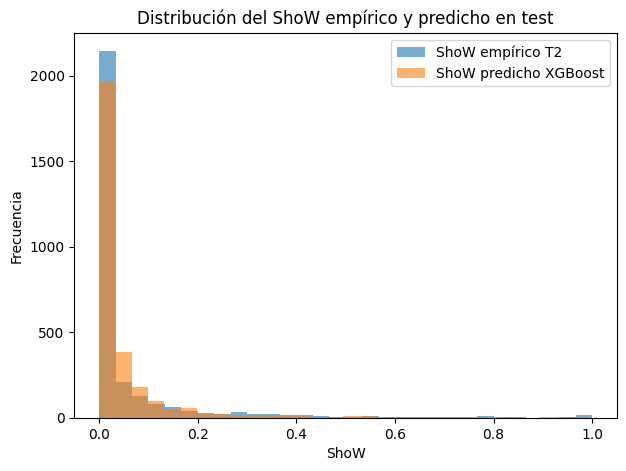

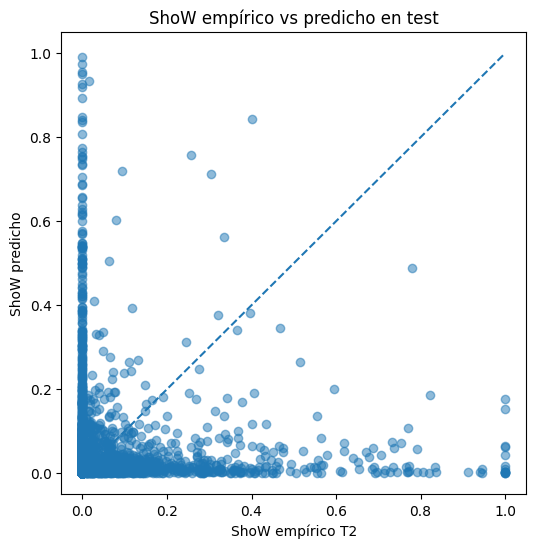

In [178]:

# ============================================================
# 13. Comparación distribución empírica vs predicha
# ============================================================
plt.figure(figsize=(7, 5))
plt.hist(y_test, bins=30, alpha=0.6, label="ShoW empírico T2")
plt.hist(pred_test, bins=30, alpha=0.6, label="ShoW predicho XGBoost")
plt.xlabel("ShoW")
plt.ylabel("Frecuencia")
plt.title("Distribución del ShoW empírico y predicho en test")
plt.legend()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("ShoW empírico T2")
plt.ylabel("ShoW predicho")
plt.title("ShoW empírico vs predicho en test")
plt.show()


In [179]:

# ============================================================
# 14. Exportar predicciones y métricas
# ============================================================
predicciones_test = test_df[[
    "Survey ResponseID",
    "gasto_samsung_T2",
    "gasto_total_electronicos_T2",
    "show_empirico"
]].copy()

predicciones_test["show_pred_xgb_reg_logistic"] = pred_test
predicciones_test["error_abs"] = (
    predicciones_test["show_empirico"] -
    predicciones_test["show_pred_xgb_reg_logistic"]
).abs()

predicciones_test.to_csv("predicciones_show_xgb_reg_logistic_test.csv", index=False)
resultados_metricas.to_csv("metricas_show_xgb_reg_logistic.csv", index=False)

predicciones_test.head()


,Survey ResponseID,gasto_samsung_T2,gasto_total_electronicos_T2,show_empirico,show_pred_xgb_reg_logistic,error_abs
2,R_038ZU6kfQ5f89fH,0.0,35.98,0.0,0.011005,0.011005
4,R_06RZP9pS7kONINr,0.0,783.75,0.0,0.043986,0.043986
6,R_07oHvj3bLVVRCRb,0.0,0.00,0.0,0.009402,0.009402
7,R_085qq7w0pkhowox,0.0,181.16,0.0,0.012953,0.012953
10,R_0Arj0ePpTnReV1v,0.0,55.65,0.0,0.025815,0.025815


In [180]:

# ============================================================
# 15. Importancia de variables
# ============================================================
feature_names = model_xgb_show.named_steps["preprocessor"].get_feature_names_out()
importances = model_xgb_show.named_steps["xgb"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "variable": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

feature_importance.head(20)


AttributeError: Estimator winsor does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()?